Categories: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


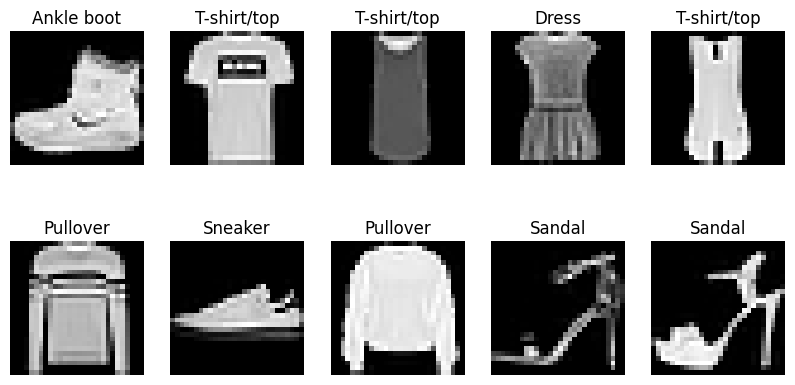

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.8307 - loss: 0.4680 - val_accuracy: 0.8704 - val_loss: 0.3674
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.8851 - loss: 0.3147 - val_accuracy: 0.8875 - val_loss: 0.3103
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9011 - loss: 0.2695 - val_accuracy: 0.8946 - val_loss: 0.2906
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 34ms/step - accuracy: 0.9129 - loss: 0.2370 - val_accuracy: 0.9049 - val_loss: 0.2605
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9228 - loss: 0.2115 - val_accuracy: 0.9030 - val_loss: 0.2688
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9030 - loss: 0.2688
Test Accuracy: 0.902999997138977


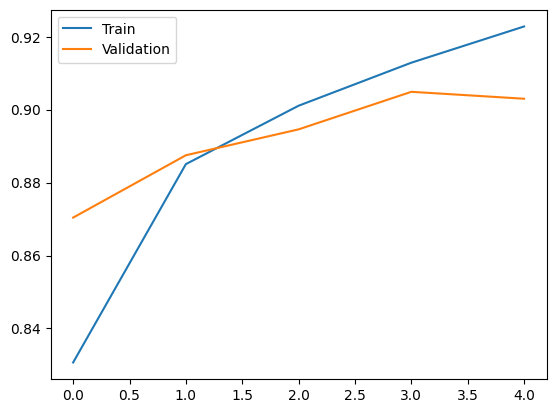

In [7]:
# Step 1: Imports
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Step 2: Load data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Step 2.1: Class names (categories)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Categories:", class_names)

# Step 2.2: Show sample images
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

# Step 3: Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 4: Reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Step 5: Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 6: Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 7: Train
history = model.fit(X_train, y_train,
                    epochs=5,
                    validation_data=(X_test, y_test))

# Step 8: Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

**OUTPUT EXPLAINATION :**

Nice — this is a **very good CNN result (~90% accuracy)** 👍
Let’s break your output in a **clear + viva-ready way**.

---

# 📦 1. DATASET CATEGORIES

```
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
```

### ✅ Meaning:

* Total **10 classes**
* Each image belongs to one clothing category
* Example:

  * 0 → T-shirt
  * 7 → Sneaker

---

# 📊 2. TRAINING PERFORMANCE (EPOCHS)

### Your results:

| Epoch | Train Accuracy | Train Loss |
| ----- | -------------- | ---------- |
| 1     | 83%            | 0.46       |
| 2     | 88%            | 0.31       |
| 3     | 90%            | 0.26       |
| 4     | 91%            | 0.23       |
| 5     | 92%            | 0.21       |

### ✅ Interpretation:

👉 Accuracy is **increasing steadily**
👉 Loss is **decreasing**

✔ This means:
👉 Model is **learning properly**

---

# 📉 3. VALIDATION PERFORMANCE

| Epoch | Val Accuracy | Val Loss |
| ----- | ------------ | -------- |
| 1     | 87%          | 0.36     |
| 2     | 88%          | 0.31     |
| 3     | 89%          | 0.29     |
| 4     | 90%          | 0.26     |
| 5     | 90%          | 0.26     |

### ✅ Interpretation:

👉 Validation accuracy is also **increasing**
👉 Validation loss is **decreasing**

✔ This means:
👉 Model is **generalizing well (no overfitting)**

---

# 🎯 4. FINAL TEST RESULT

```
Test Accuracy: 0.903 (~90%)
```

### ✅ Meaning:

👉 Model correctly classifies:
➡️ **~90% of clothing images**

✔ This is a **strong performance** for Fashion MNIST

---

# 🔥 5. FINAL CONCLUSION (VERY IMPORTANT)

👉 *“The model shows increasing training and validation accuracy with decreasing loss, indicating proper learning and good generalization. The final test accuracy is around 90%, which shows the CNN model performs effectively for image classification.”*

---

# ⚖️ 6. IS THERE OVERFITTING?

❌ No major overfitting

Why?

* Train accuracy ≈ 92%
* Validation accuracy ≈ 90%

👉 Difference is small → **good model**

---

# 📈 7. WHAT YOUR GRAPH WILL SHOW

👉 Two lines:

* Training accuracy (slightly higher)
* Validation accuracy (close to training)

✔ Both increasing → **ideal learning**

---

# 🧠 8. QUICK MEMORY (for viva)

👉 Accuracy ↑ → learning
👉 Loss ↓ → improving
👉 Train ≈ Validation → good model

---

# ⚡ BONUS (if examiner asks “how to improve?”)

You can say:

* Add **Dropout**
* Increase epochs
* Add more CNN layers
* Data augmentation

🧠 KEY POINTS (REMEMBER)
CNN → used for image data
Conv2D → feature extraction
MaxPooling → reduce size
Flatten → convert to vector
Output → 10 classes → softmax


Here are **high-probability viva questions** for your **CNN practical (Fashion MNIST + Plant Disease Detection)**.
These are exactly the kind of things examiners ask 👇

---

# 🎯 BASIC QUESTIONS (must know)

### 1. What is CNN?

* A **Convolutional Neural Network** used mainly for **image processing**

---

### 2. Why CNN instead of ANN?

* CNN automatically extracts **spatial features (edges, patterns)**
* ANN cannot handle images efficiently

---

### 3. Applications of CNN?

* Image classification
* Object detection
* Medical imaging
* Plant disease detection

---

# 🧠 CNN ARCHITECTURE QUESTIONS

### 4. What is Conv2D layer?

* Applies filters to extract features like edges, textures

---

### 5. What is kernel/filter?

* Small matrix used to scan image

---

### 6. What is MaxPooling?

* Reduces image size while keeping important features

---

### 7. Why use pooling?

* Reduce computation
* Prevent overfitting

---

### 8. What is Flatten layer?

* Converts 2D feature maps into 1D vector

---

### 9. What is Dense layer?

* Fully connected layer for classification

---

# ⚙️ TRAINING RELATED

### 10. What is activation function used?

* ReLU (hidden layers)
* Softmax (output layer)

---

### 11. Why use ReLU?

* Faster training
* Avoids vanishing gradient

---

### 12. Why use softmax?

* Converts output into probabilities

---

### 13. What is loss function used?

* `categorical_crossentropy` or `sparse_categorical_crossentropy`

---

### 14. What is optimizer?

* Adam (used to update weights)

---

# 👕 FASHION MNIST QUESTIONS

### 15. What is Fashion MNIST dataset?

* Dataset of clothing images (10 classes)

---

### 16. Image size?

* 28 × 28 grayscale

---

### 17. Number of classes?

* 10 (T-shirt, shoe, bag, etc.)

---

### 18. Why reshape data?

* CNN requires 4D input → (samples, height, width, channels)

---

# 🌿 PLANT DISEASE QUESTIONS

### 19. How dataset is loaded?

* Using `ImageDataGenerator` from folders

---

### 20. Why rescale images?

* Normalize pixel values (0–255 → 0–1)

---

### 21. What is class_mode='categorical'?

* For multiclass classification

---

### 22. What is target_size?

* Resize images to fixed size

---

# 📊 PERFORMANCE QUESTIONS

### 23. What is accuracy?

* % of correct predictions

---

### 24. Training vs validation accuracy?

* Training → seen data
* Validation → unseen data

---

### 25. What is overfitting?

* Model performs well on training but poorly on validation

---

### 26. How to reduce overfitting?

* Dropout
* Data augmentation
* Reduce layers

---

# 🔥 IMPORTANT DIFFERENCE QUESTIONS

### 27. CNN vs ANN

| CNN                       | ANN                         |
| ------------------------- | --------------------------- |
| Works on images           | Works on tabular data       |
| Uses convolution          | Uses fully connected layers |
| Extracts spatial features | No spatial awareness        |

---

### 28. MaxPooling vs AveragePooling

| MaxPooling            | AveragePooling   |
| --------------------- | ---------------- |
| Takes max value       | Takes average    |
| Keeps strong features | Smooths features |

---

# ⚡ ADVANCED (to impress examiner)

### 29. What is feature map?

* Output of convolution layer

---

### 30. What is stride?

* Step size of filter movement

---

### 31. What is padding?

* Adding pixels around image to preserve size

---

### 32. What is dropout?

* Randomly disables neurons to prevent overfitting

---

# 🎯 READY-MADE VIVA ANSWER

👉 *“CNN consists of convolution, pooling, and fully connected layers. It automatically extracts features from images and performs classification using softmax activation.”*

---

# 🧠 1-MINUTE REVISION

👉 Conv → feature extraction
👉 Pool → reduce size
👉 Flatten → convert to vector
👉 Dense → classification
👉 Softmax → multiclass output